In [1]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(df.shape)

print(df.columns)

df.info()


(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df = df.dropna()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
print("Total Customers")

print(df.shape[0])


Total Customers
7043


In [12]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [13]:
churn_rate = df["Churn"].value_counts(normalize=True)*100

print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


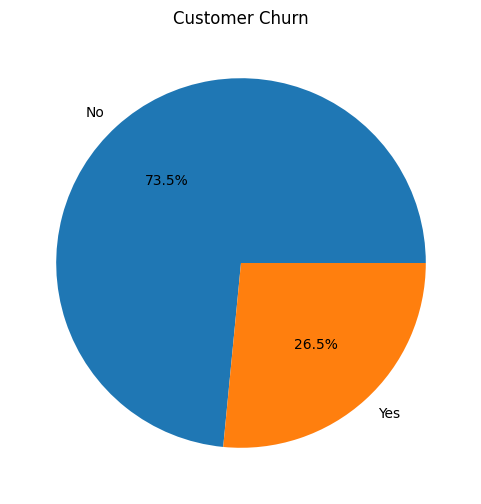

In [14]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.title("Customer Churn")

plt.ylabel("")

plt.show()

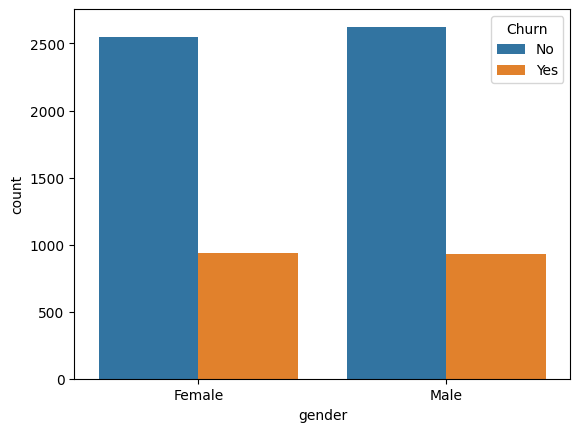

In [15]:
sns.countplot(
data=df,
x="gender",
hue="Churn"
)

plt.show()

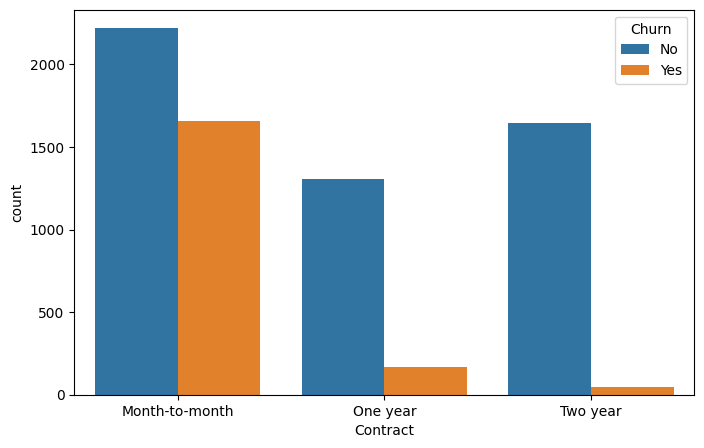

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
data=df,
x="Contract",
hue="Churn"
)

plt.show()

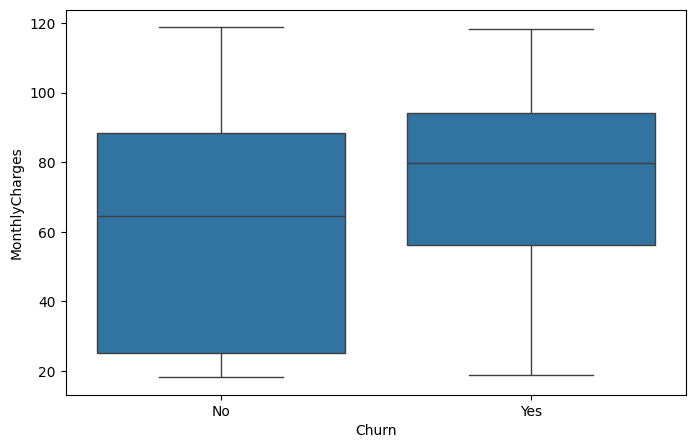

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
data=df,
x="Churn",
y="MonthlyCharges"
)

plt.show()

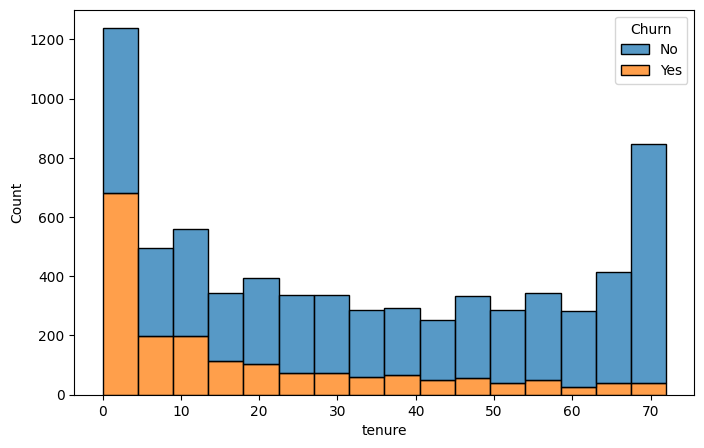

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
data=df,
x="tenure",
hue="Churn",
multiple="stack"
)

plt.show()

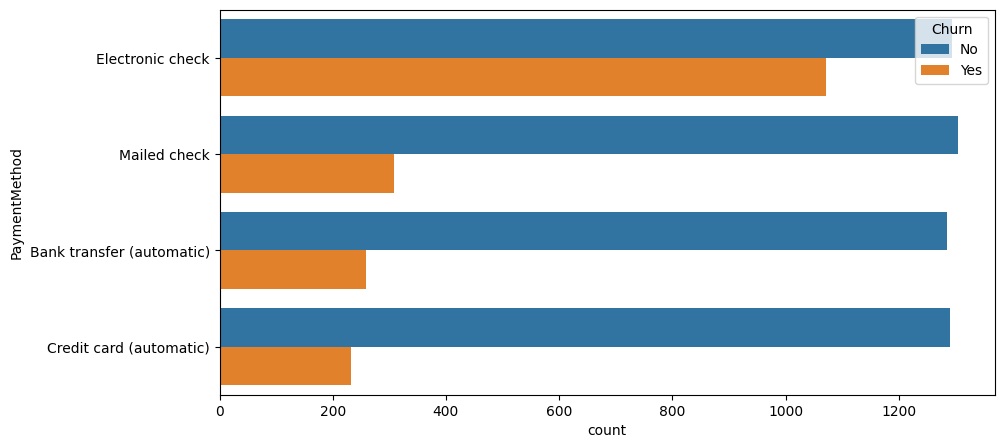

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
data=df,
y="PaymentMethod",
hue="Churn"
)

plt.show()

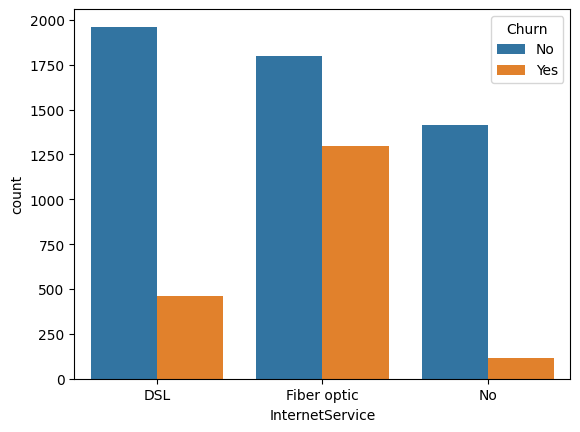

In [20]:
sns.countplot(
data=df,
x="InternetService",
hue="Churn"
)

plt.show()

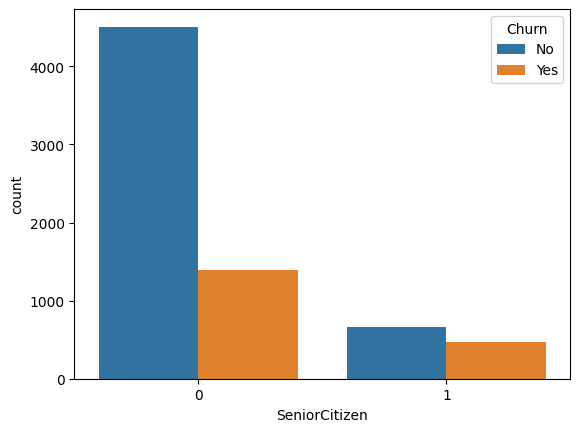

In [21]:
sns.countplot(
data=df,
x="SeniorCitizen",
hue="Churn"
)

plt.show()

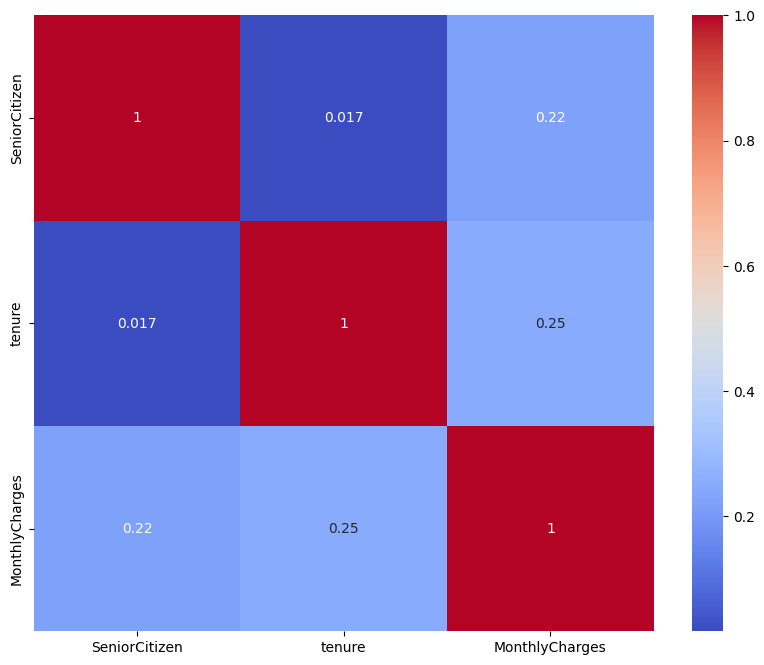

In [22]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
numeric.corr(),
annot=True,
cmap="coolwarm"
)

plt.show()

In [25]:
fig = px.sunburst(
df,
path=["Contract","InternetService","Churn"]
)

fig.show()

# Business Insights

## Customer Retention & Churn Analysis

1. Customers with **month-to-month contracts** have the highest churn compared to customers with one-year and two-year contracts.

2. Customers using **Fiber Optic internet service** show a higher churn rate than DSL users.

3. Most customers are **not senior citizens**, and the majority of retained customers belong to this group.

4. Customers with **longer contract periods** are more likely to remain with the company.

5. Contract type and internet service appear to be major factors affecting customer churn.

# Recommendations

1. Encourage customers to move from month-to-month plans to one-year or two-year contracts by offering discounts or rewards.

2. Improve the quality and customer support for Fiber Optic internet services to reduce churn.

3. Introduce loyalty programs for long-term customers to increase retention.

4. Identify customers who are at high risk of churning and provide personalized offers before they leave.

5. Monitor customer satisfaction regularly and resolve service issues quickly.